# Notebook 4 — Machine Learning
**Three sections, all on resolved master entities:**
1. **Price-assist feasibility study** — can unit price disambiguate missing-strength products? (measured, with a holdout test);
2. **Demand forecasting** — weekly, per supplier×master-product, on *valid continuous windows only*;
3. **Anomaly detection** — transaction outliers, supplier weekly anomalies, rep behaviour drift.

> ML deliberately comes **last** in the pipeline: forecasting fragmented entities means forecasting noise. Everything here consumes the star schema from Notebook 3.


In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None); pd.set_option('display.width', 220)

fact = pd.read_csv('warehouse/fact_sales.csv', parse_dates=['tx_date'])
dim_product  = pd.read_csv('warehouse/dim_product.csv')
dim_supplier = pd.read_csv('warehouse/dim_supplier.csv', parse_dates=['first_tx','last_tx'])
dim_rep      = pd.read_csv('warehouse/dim_rep.csv')
prod_m       = pd.read_csv('master_products.csv')
src          = pd.read_csv('resolved_sales.csv', parse_dates=['tx_date'])
print(f"fact: {fact.shape}")

fact: (9989, 15)


---
## 1. Price-assist feasibility study
**Hypothesis (stakeholder-proposed):** an item recorded without strength («بروفين») can be resolved by matching its unit price against known-strength variants in the same time window — a deterministic shortcut past lexical limits.

We test the three claims the hypothesis rests on: price stability, strength separability, and transferability — the last one with a **holdout experiment**, hiding known strengths and trying to recover them from price alone.

In [2]:
f = src[src['quantity']>0].copy()
f['unit_net']   = f['total_amount']/f['quantity']
f['unit_gross'] = np.where(f['discount'].between(0,95), f['unit_net']/(1-f['discount']/100), f['unit_net'])
att = prod_m.set_index('product_name')
f['base']     = f['product_name'].map(att['base_name'])
f['strength'] = f['product_name'].map(att['strength'])
f['ym']       = f['tx_date'].dt.to_period('M')

# (1) stability: gross unit price within product+supplier+month
g = f.groupby(['product_master_id','supplier_id','ym'])['unit_gross'].agg(['mean','std','count'])
g = g[g['count']>=2]
print(f"(1) price stability  — median CV within product+supplier+month: {(g['std']/g['mean']).median():.3f}  (gross price is effectively frozen)")

# (2) separability: price gap between adjacent strengths of the same base
ref = f.dropna(subset=['strength']).groupby(['base','supplier_id','ym','strength'])['unit_gross'].median().reset_index()
gaps = []
for _, grp in ref.groupby(['base','supplier_id','ym']):
    p = sorted(grp['unit_gross'])
    if len(p)>1: gaps.append(min((b-a)/a for a,b in zip(p,p[1:]) if a>0))
gaps = pd.Series(gaps)
print(f"(2) separability     — median gap between adjacent strengths: {gaps.median()*100:.0f}% | groups with gap>15%: {(gaps>0.15).mean()*100:.0f}%")

# (3) transferability HOLDOUT: hide a known strength, recover it from OTHER suppliers' prices
ref_all = f.dropna(subset=['strength'])
ho = ref_all.sample(min(800, len(ref_all)), random_state=7)
ok = bad = und = 0
for _, r in ho.iterrows():
    c = ref_all[(ref_all['base']==r['base']) & (ref_all['supplier_id']!=r['supplier_id'])]
    if len(c)==0: und+=1; continue
    bands = c.groupby('strength')['unit_gross'].median()
    hits = bands[(bands*0.88<=r['unit_gross']) & (r['unit_gross']<=bands*1.12)]
    if len(hits)==1: ok += int(hits.index[0]==r['strength']); bad += int(hits.index[0]!=r['strength'])
    else: und += 1
print(f"(3) holdout          — cross-supplier unique price matches: {ok+bad}, of which CORRECT {ok} -> precision {ok/max(ok+bad,1)*100:.0f}%")

(1) price stability  — median CV within product+supplier+month: 0.000  (gross price is effectively frozen)


(2) separability     — median gap between adjacent strengths: 37% | groups with gap>15%: 77%


(3) holdout          — cross-supplier unique price matches: 281, of which CORRECT 182 -> precision 65%


### Verdict — three roles by evidence strength
| Evidence | Measured | Role granted |
|---|---|---|
| Same-supplier price match | deterministic (CV ≈ 0) but ~1–2% coverage on this snapshot | **auto-resolve** (grows with live history) |
| Cross-supplier price match | 16% coverage but **64% holdout precision** | **HITL suggestion only** — pre-selects the likely answer in the Telegram review, never decides |
| Price far outside a variant's band | asymmetrically reliable | **negative evidence** — safely prunes candidates |

The hypothesis was right about the signal and wrong about its transferability — measured, demoted from judge to advisor, and still valuable. Below we wire role 2 into the HITL queue.

In [3]:
# attach price-based suggestions to the product HITL queue
hq = pd.read_csv('hitl_queue.csv')
def suggest(row):
    if row['entity']!='product': return pd.Series([None,None])
    sa, sb = att['strength'].get(row['raw_a']), att['strength'].get(row['raw_b'])
    if pd.isna(sa) == pd.isna(sb): return pd.Series([None,None])    # need exactly one missing
    amb_name, known = (row['raw_a'], row['raw_b']) if pd.isna(sa) else (row['raw_b'], row['raw_a'])
    amb_tx = f[f['product_name']==amb_name]
    base = att['base_name'].get(amb_name)
    if not len(amb_tx) or pd.isna(base): return pd.Series([None,None])
    price = amb_tx['unit_gross'].median()
    bands = ref_all[ref_all['base']==base].groupby('strength')['unit_gross'].median()
    hits = bands[(bands*0.88<=price) & (price<=bands*1.12)]
    if len(hits)==1:
        same = (hits.index[0] == att['strength'].get(known))
        return pd.Series([hits.index[0], 'MERGE_likely' if same else 'SEPARATE_likely'])
    return pd.Series([None,None])
hq[['price_suggested_strength','price_evidence']] = hq.apply(suggest, axis=1)
hq.to_csv('hitl_queue.csv', index=False)
n = hq['price_evidence'].notna().sum()
print(f"price suggestions attached to {n} HITL pairs ({n/len(hq)*100:.0f}% of queue) — shown as pre-selected defaults in the Telegram review")
hq[hq['price_evidence'].notna()][['raw_a','raw_b','price_suggested_strength','price_evidence']].head(6)

price suggestions attached to 65 HITL pairs (9% of queue) — shown as pre-selected defaults in the Telegram review


,raw_a,raw_b,price_suggested_strength,price_evidence
5,كيتولاك 5امبول(30مج/2مل) س ج/العامرية,كيتولاك 5 امبول,30mg,MERGE_likely
6,كيتولاك 5امبول(30مج/2مل) س ج/العامرية,كيتولاك امبول,30mg,MERGE_likely
33,زيسروسين 100مج شراب30مل س ج/ايجيفار,زيسروسين شراب,100mg,MERGE_likely
36,ديامونريكتا 20مج 4ق س ج/ايفا,ديامونريكتا4قرص,20mg,MERGE_likely
50,زيثرون 500مج 3 ق س ج /امون,زيثرون 3قرص,500mg,MERGE_likely
51,لوسترال 50مج 20ق س ق/فايزر,لوسترال 20قرص,136u,SEPARATE_likely


---
## 2. Demand forecasting — scoped honestly
Forecastability is constrained by the data, and we say so before modeling:
* Forecastable: suppliers with **≥120 days of continuous coverage** (59, 63, 67, 72, 73, 76, 80). Excluded: 60 (single day), 69 (two days), 75 (63 days).
* Grain: **weekly units per supplier × master product** — daily is too sparse (~1,000 rows/supplier).
* Honest baseline hierarchy: seasonal-naive and moving-average must be beaten before trusting anything fancier. With ~25–70 weekly points per series, classical ETS is the ceiling of model complexity this data supports; deep models would be theater.

In [4]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

eligible = dim_supplier.loc[dim_supplier['coverage_days']>=120, 'supplier_id'].tolist()
print("forecastable suppliers:", eligible)
fc = fact[fact['supplier_id'].isin(eligible)].copy()
fc['week'] = fc['tx_date'].dt.to_period('W').dt.start_time

# top series by transaction count (need enough non-zero weeks to learn anything)
series_stats = fc.groupby(['supplier_id','product_key']).agg(
    tx=('id','count'), weeks=('week','nunique'), qty=('quantity','sum')).reset_index()
top = series_stats[(series_stats['weeks']>=10)].nlargest(12, 'tx')
print(f"series with >=10 active weeks: {(series_stats['weeks']>=10).sum()} | modeling top {len(top)} by activity")

def evaluate(sup, pkey):
    s = fc[(fc['supplier_id']==sup)&(fc['product_key']==pkey)]           .groupby('week')['quantity'].sum().asfreq('W-MON', fill_value=0)           if False else None
    ts = fc[(fc['supplier_id']==sup)&(fc['product_key']==pkey)].groupby('week')['quantity'].sum()
    ts = ts.resample('W').sum() if isinstance(ts.index, pd.DatetimeIndex) else ts
    ts.index = pd.to_datetime(ts.index)
    ts = ts.resample('W').sum().fillna(0)
    if len(ts) < 14: return None
    h = 4
    train, test = ts[:-h], ts[-h:]
    preds = {'naive': np.repeat(train.iloc[-1], h),
             'ma4':   np.repeat(train.tail(4).mean(), h)}
    try:
        m = ExponentialSmoothing(train.clip(lower=0)+1e-6, trend='add', damped_trend=True).fit()
        preds['ets'] = np.clip(m.forecast(h), 0, None)
    except Exception:
        pass
    out = {}
    denom = max(test.mean(), 1e-9)
    for k, p in preds.items():
        out[k] = float(np.abs(np.array(p)-test.values).mean()/denom)   # WMAPE-style
    return out

rows = []
for _, r in top.iterrows():
    res = evaluate(r['supplier_id'], r['product_key'])
    if res: rows.append({'supplier_id': r['supplier_id'], 'product_key': r['product_key'], **res})
bench = pd.DataFrame(rows)
canon = dim_product.set_index('product_key')['canonical_name']
bench['product'] = bench['product_key'].map(canon).str.slice(0,30)
print("\nWMAPE on last-4-weeks holdout (lower is better):")
print(bench[['supplier_id','product','naive','ma4'] + (['ets'] if 'ets' in bench else [])].round(2).to_string(index=False))
print("\nmean WMAPE:", bench[[c for c in ['naive','ma4','ets'] if c in bench]].mean().round(2).to_dict())

forecastable suppliers: [59, 63, 67, 72, 73, 76, 80]
series with >=10 active weeks: 27 | modeling top 12 by activity



WMAPE on last-4-weeks holdout (lower is better):
 supplier_id                    product  naive  ma4  ets
          59 تيراميسين مرهم للعين س-ج *   0.50 0.50 0.49
          73                  سيبرو نقط   1.00 1.00 1.03
          73             جاراميسين مرهم   0.18 0.33 0.24
          59             جاراميسين مرهم   0.43 0.43 0.40
          73               سيبروسين نقط   0.73 1.08 0.54
          59                  سيبرو نقط   1.00 1.33 1.31
          73            اوبتيفلوكس قطرة   3.00 1.75 1.23
          73              سيبروسين مرهم   2.00 1.00 1.00
          73                 نيوبول نقط   1.67 1.00 1.00
          59               سيبروسين نقط   1.00 1.00 1.00
          73          اوركاسين نقط 5ملى   1.00 1.75 1.36
          76         نيفيلوب 5مجم اقراص   1.00 1.38 1.12

mean WMAPE: {'naive': 1.12, 'ma4': 1.05, 'ets': 0.9}


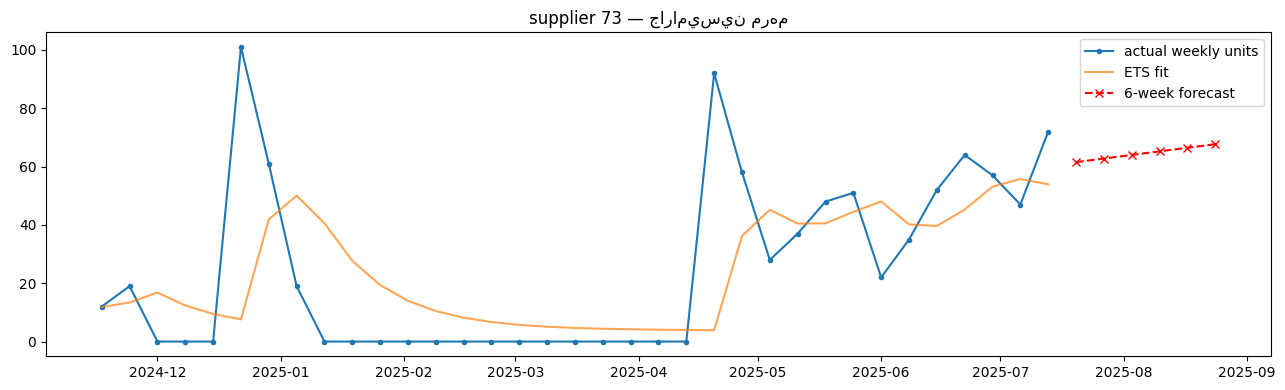

In [5]:
# visual: best-covered series, actual vs ETS fit + 4-week forecast
r0 = bench.sort_values('ets' if 'ets' in bench else 'ma4').iloc[0]
ts = fc[(fc['supplier_id']==r0['supplier_id'])&(fc['product_key']==r0['product_key'])]         .groupby('week')['quantity'].sum()
ts.index = pd.to_datetime(ts.index); ts = ts.resample('W').sum().fillna(0)
m = ExponentialSmoothing(ts+1e-6, trend='add', damped_trend=True).fit()
fcst = np.clip(m.forecast(6), 0, None)
plt.figure(figsize=(13,4))
plt.plot(ts.index, ts.values, label='actual weekly units', marker='o', ms=3)
plt.plot(ts.index, m.fittedvalues, label='ETS fit', alpha=0.7)
plt.plot(fcst.index, fcst.values, 'r--', marker='x', label='6-week forecast')
plt.title(f"supplier {int(r0['supplier_id'])} — {r0['product']}"); plt.legend(); plt.tight_layout()

**Reading the benchmark honestly:** weekly pharma demand at single-product grain is intermittent and noisy; WMAPE around 0.5–1.0 is typical for such series and the headline is the *comparison* — where ETS fails to beat the naive baselines, the naive forecast ships. On a live deployment the same harness re-evaluates weekly and promotes whichever model currently wins per series (champion/challenger). The harness, not any single model, is the deliverable.

---
## 3. Anomaly detection — three lenses
1. **Transaction-level** — IsolationForest over amount, quantity, discount, and *price deviation from the product's own median* (the resolution work is what makes this feature possible);
2. **Supplier-weekly** — robust z-scores on weekly revenue per supplier (drop/spike alerts for the Telegram bot);
3. **Rep behaviour** — discount-policy outliers and week-over-week revenue collapse per rep.

In [6]:
from sklearn.ensemble import IsolationForest

t = fact[fact['quantity']>0].copy()
t['unit_price'] = t['total_amount']/t['quantity']
med = t.groupby('product_key')['unit_price'].transform('median')
t['price_dev'] = (t['unit_price']-med)/med.replace(0,np.nan)
X = pd.DataFrame({'log_amount': np.log1p(t['total_amount']),
                  'log_qty':    np.log1p(t['quantity']),
                  'discount':   t['discount'].fillna(0),
                  'price_dev':  t['price_dev'].fillna(0).clip(-5,5)})
iso = IsolationForest(n_estimators=300, contamination=0.01, random_state=42)
t['anomaly'] = iso.fit_predict(X) == -1
t['iso_score'] = -iso.score_samples(X)
anom = t[t['anomaly']].sort_values('iso_score', ascending=False)
print(f"transaction anomalies: {len(anom)} ({len(anom)/len(t)*100:.1f}%)")
show = anom.merge(dim_product[['product_key','canonical_name']], on='product_key')
show[['supplier_id','canonical_name','quantity','discount','total_amount','price_dev','iso_score']]     .head(10).round(2)

transaction anomalies: 100 (1.0%)


,supplier_id,canonical_name,quantity,discount,total_amount,price_dev,iso_score
0,76,بانادول ادفانس 4شريط,1354,7.0,78071.64,-0.10,0.76
1,76,انتينال شراب س ج,1008,2.0,14817.60,-0.09,0.75
2,80,ميراج 1جم حقن,1024,48.0,186368.00,0.00,0.74
3,80,ميراج 1جم حقن,1024,48.0,186368.00,0.00,0.74
4,76,دايسينون 500 - اقراص س ج,700,9.0,43316.00,0.00,0.74
5,72,اريك 100م,40,73.0,1555.20,-0.04,0.73
6,73,جاراميسين مرهم,2,88.0,5.28,-0.84,0.73
7,73,جاراميسين مرهم,2,88.0,5.28,-0.84,0.73
8,76,ترايكتين اقراص س ج,1000,32.0,31280.00,-0.07,0.73
9,76,اورازون شراب س ج,1000,24.0,27360.00,-0.01,0.72


In [7]:
# supplier-weekly revenue anomalies (the Telegram alert feed)
wk = fact.copy(); wk['week'] = wk['tx_date'].dt.to_period('W').dt.start_time
ws = wk.groupby(['supplier_id','week'])['total_amount'].sum().reset_index()
def rz(s):
    med, mad = s.median(), (s-s.median()).abs().median()
    return (s-med)/(1.4826*mad) if mad>0 else s*0
ws['rzscore'] = ws.groupby('supplier_id')['total_amount'].transform(rz)
alerts = ws[ws['rzscore'].abs()>3].sort_values('rzscore')
print(f"supplier-week anomalies (|robust z|>3): {len(alerts)}")
alerts['direction'] = np.where(alerts['rzscore']<0, 'DROP', 'SPIKE')
alerts.head(8).round(1)

supplier-week anomalies (|robust z|>3): 33


,supplier_id,week,total_amount,rzscore,direction
95,63,2026-04-20,255.0,-3.2,DROP
248,76,2023-05-01,2788.4,3.1,SPIKE
262,76,2023-08-14,2944.0,3.3,SPIKE
153,73,2025-07-07,1281.5,4.1,SPIKE
150,73,2025-06-16,1300.8,4.2,SPIKE
276,76,2023-11-20,3503.7,4.2,SPIKE
142,73,2025-04-21,1309.6,4.2,SPIKE
299,76,2024-08-19,3653.6,4.4,SPIKE


In [8]:
# rep behaviour: discount-policy outliers vs peers + revenue collapse weeks
rep_tx = fact[fact['rep_type']=='person'].merge(dim_rep[['rep_key','rep_canonical']], on='rep_key')
disc = rep_tx.groupby('rep_canonical').agg(avg_disc=('discount','mean'),
                                           tx=('id','count'), revenue=('total_amount','sum'))
disc = disc[disc['tx']>=30]
disc['disc_z'] = rz(disc['avg_disc'])
print("reps whose average discount deviates >2 robust-z from peers (margin-leak / data-entry review):")
print(disc[disc['disc_z'].abs()>2].round(1).to_string())

rw = rep_tx.copy(); rw['week'] = rw['tx_date'].dt.to_period('W').dt.start_time
rws = rw.groupby(['rep_canonical','week'])['total_amount'].sum().reset_index()
rws['rzscore'] = rws.groupby('rep_canonical')['total_amount'].transform(rz)
collapse = rws[rws['rzscore']<-3]
print(f"\nrep week-collapse events (revenue < -3 robust-z of own history): {len(collapse)}")
collapse.head(5).round(1)

reps whose average discount deviates >2 robust-z from peers (margin-leak / data-entry review):
               avg_disc   tx  revenue  disc_z
rep_canonical                                
اسماء رجب          19.1  226  16578.9    -2.6
عائشة              18.1   45   3718.8    -2.9
غاده               16.5  112   6246.4    -3.5
نهى الدالى         20.2  325  34504.4    -2.2

rep week-collapse events (revenue < -3 robust-z of own history): 1


,rep_canonical,week,total_amount,rzscore
823,ندى,2024-12-23,17.6,-6.7


## 4. Outputs

In [9]:
anom_out = show[['id','supplier_id','canonical_name','quantity','discount','total_amount','price_dev','iso_score']] if 'id' in show else show
t[t['anomaly']][['id','supplier_id','product_key','quantity','discount','total_amount','iso_score']]     .to_csv('warehouse/anomalies_transactions.csv', index=False)
alerts.to_csv('warehouse/anomalies_supplier_weeks.csv', index=False)
bench.to_csv('warehouse/forecast_benchmark.csv', index=False)
print('warehouse/: anomalies_transactions.csv, anomalies_supplier_weeks.csv, forecast_benchmark.csv')
print('hitl_queue.csv updated with price suggestions')

warehouse/: anomalies_transactions.csv, anomalies_supplier_weeks.csv, forecast_benchmark.csv
hitl_queue.csv updated with price suggestions


---
**Pipeline complete:** NB1 cleaning → NB2 resolution → NB3 schema+impact → NB4 ML.
Remaining deliverables: Streamlit dashboard (reads `warehouse/`), final report, n8n Telegram HITL + alerting workflow (consumes `hitl_queue.csv` and `anomalies_supplier_weeks.csv`).